<hr style="border:2px solid #CC00FF;">

<!-- Contenedor ultra-compatible. Usamos 'height' en lugar de 'width' para lograr simetría visual -->
<p align="center">
    <a href="https://medellin.unal.edu.co" target="_blank">
        <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR9ItLTT_F-3Q30cu7ZCCoKmuFGBt22pe7pNA" height="75" alt="Logo UNAL">
    </a>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
    <a href="https://minaslap.net/?redirect=0" target="_blank">
        <img src="https://minaslap.net/pluginfile.php/1/core_admin/logo/0x200/1770226238/Logo%20MinasLAP-3%20%281%29.png" height="75" alt="Logo MinasLAP">
    </a>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
    <a href="https://micampus.unal.edu.co" target="_blank">
        <img src="https://micampus.unal.edu.co/pluginfile.php/1/theme_almondb/sliderimage1/1788871931/Slider_1.png" height="75" alt="Logo MiCampus">
    </a>
</p>

<!-- Títulos usando alineación clásica compatible con IDEs -->
<h1 align="center">Optimización e IA 2026-2S</h1>
<h2 align="center">Práctica 1</h2>
<h3 align="center">Parte 3: Optimización de hiperparámetros para Random Forest</h3>
<p align="center">
    Departamento de Ciencias de la Computación y de la Decisión<br>
    Facultad de Minas<br>
    Universidad Nacional de Colombia<br>
    Docente: Maria Constanza Torres Madronero
</p>

<div id="conte"></div>
<hr style="border:2px solid #CC00FF;">

**Elaborado por:** _Kevin Ferney Hidalgo Higuita_

**Correo:** _kfhidalgoh@unal.edu.co_

**Fecha de elaboración:** _12 de septiembre de 2026_

**Fecha última modificación:** _12 de septiembre de 2026_

**Repositorio:** [![GitHub Repository](https://img.shields.io/badge/repository-GitHub-181717.svg)](https://github.com/KevinHidalgoDS/optimizacion-ia)

*Nota: el tema del navegador para visualizar HTML puede afectar el comportamiento de la presentación.*

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import datasets, metrics
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.preprocessing import MinMaxScaler
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical
from src.utils import logger as log
from src.utils.estiloDashboard import estilo_dashboard

logger = log.LOGGER
config = log.CONFIG
logger.info("Python %s on %s", sys.version, sys.platform)

plt.style.use("ggplot")
%matplotlib inline

2026-09-16 18:43:29 [INFO] Python 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)] on win32


1. Explore la clasificación usando RandomForest sobre los datos Digits (sklearn.datasets.load_digits), que incluye 180 imágenes (8x8) de los dígitos del 0 al 10. Optimice los hiperparámetros empleando los métodos de búsqueda de grilla, búsqueda aleatoria y optimización bayesiana, presente tanto la precisión general de clasificación como la matriz de confusión.
2. Explore la regresión usando RandomForest con los datos de California Housing (sklearn.datasets.fetch_california_housing). Este dataset busca estimar el valor de una vivienda a partir de 8 características. Optimice los hiperparámetros empleando los métodos de búsqueda de grilla, búsqueda aleatoria y optimización bayesiana y compare las diferentes métricas de desempeño.

## Solución

### 1. Clasificación

#### Carga de dataset

In [84]:
digits = datasets.load_digits()

logger.debug("contenido de digits: \n%s", digits.keys())

# Organizando dataframe
df = pd.DataFrame(data=digits.data, columns=digits.feature_names)

# Se agrega la columna correspondiente a la variable objetivo.
df['target'] = digits.target

estilo_dashboard(df.head().T)

2026-09-17 00:08:06 [DEBUG] contenido de digits: 
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


,0,1,2,3,4
pixel_0_0,0.00,0.00,0.00,0.00,0.00
pixel_0_1,0.00,0.00,0.00,0.00,0.00
pixel_0_2,5.00,0.00,0.00,7.00,0.00
pixel_0_3,13.00,12.00,4.00,15.00,1.00
pixel_0_4,9.00,13.00,15.00,13.00,11.00
pixel_0_5,1.00,5.00,12.00,1.00,0.00
pixel_0_6,0.00,0.00,0.00,0.00,0.00
pixel_0_7,0.00,0.00,0.00,0.00,0.00
pixel_1_0,0.00,0.00,0.00,0.00,0.00
pixel_1_1,0.00,0.00,0.00,8.00,0.00


#### División datos de entrenamiento y prueba

In [13]:
# 1. Separar las características (X) y la variable a predecir (y)
# X contendrá solo las 64 columnas de los píxeles
X = df.drop('target', axis=1)
# y contendrá solo las etiquetas (el número real)
y = df['target']

# 2. Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificar la cantidad de datos en cada conjunto
print(f"Total de imágenes originales: {df.shape[0]}")
print(f"Imágenes para entrenamiento (X_train): {X_train.shape[0]}")
print(f"Imágenes para prueba (X_test): {X_test.shape[0]}")

Total de imágenes originales: 1797
Imágenes para entrenamiento (X_train): 1437
Imágenes para prueba (X_test): 360


#### Normalización

Se puede usar MinMaxScaler() por la escala de los datos

In [18]:
# objeto escalador
scaler = MinMaxScaler()

# Ajustar y transformar los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Transformar SOLAMENTE los datos de prueba
X_test_scaled = scaler.transform(X_test)

logger.debug("Valor máximo original en X_train: %s", X_train.max().max())
logger.debug("Valor máximo escalado en X_train_scaled: %s", X_train_scaled.max())

2026-09-16 19:17:30 [DEBUG] Valor máximo original en X_train: 16.0
2026-09-16 19:17:30 [DEBUG] Valor máximo escalado en X_train_scaled: 1.0


#### Optimizacion de hiperparametros usando busqueda de grilla

In [28]:
# Clasificador base
rf = RandomForestClassifier(
    min_samples_leaf=1,       # S6973
    max_features="sqrt",      # S6973
    random_state=42
)

# Definicion de la "cuadrícula" (grid) de hiperparámetros a explorar
param_grid = {
    'n_estimators': np.arange(10, 200, 20),       # Cantidad de árboles en el bosque
    'max_depth': [10, 20],          # Profundidad máxima de cada árbol
    'min_samples_split': [2, 5],          # Mínimo de muestras para dividir un nodo
    'min_samples_leaf': [1, 2],           # Mínimo de muestras que debe haber en una "hoja" final
    'criterion': ['gini','entropy']
}

# Configuracion GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,               # El modelo que vamos a usar
    param_grid=param_grid,      # El diccionario con los parámetros a probar
    cv=5,                       # Validación cruzada de 5 pliegues (divide X_train en 5 partes)
    n_jobs=-1,                  # Usa todos los núcleos de tu procesador para ir más rápido
    scoring='accuracy'          # Métrica a optimizar (exactitud)
)

# Iniciar la búsqueda y el entrenamiento
logger.info("Buscando los mejores parámetros... Esto puede tomar unos segundos.")
grid_search.fit(X_train, y_train)

2026-09-16 20:10:08 [INFO] Buscando los mejores parámetros... Esto puede tomar unos segundos.


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [10, 20], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verb

In [30]:
# Ver los resultados
logger.info("\n¡Búsqueda completada!")
logger.info("Mejores hiperparámetros encontrados: \n%s", grid_search.best_params_)
logger.info("Mejor exactitud durante la validación cruzada: %.2f%%", grid_search.best_score_ * 100)

# Guardar el mejor modelo listo para usarse
best_rf_model = grid_search.best_estimator_

2026-09-16 20:12:08 [INFO] 
¡Búsqueda completada!
2026-09-16 20:12:08 [INFO] Mejores hiperparámetros encontrados: 
{'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': np.int64(190)}
2026-09-16 20:12:08 [INFO] Mejor exactitud durante la validación cruzada: 97.56


In [43]:
# Usar el modelo para predecir las etiquetas de los datos de prueba
y_pred = best_rf_model.predict(X_test)

# Calcular la exactitud (accuracy) general
precision_final = metrics.accuracy_score(y_test, y_pred)
logger.info("Precisión exacta en el conjunto de prueba: %.2f%%", precision_final * 100)

# Generar un reporte detallado para ver cómo le fue con cada número
logger.info("Reporte de Clasificación Detallado:")
report = metrics.classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# redondear y ordenar
df_report = df_report.round(3)
df_report
# df_report.style.background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])

2026-09-16 20:36:58 [INFO] Precisión exacta en el conjunto de prueba: 97.78%
2026-09-16 20:36:58 [INFO] Reporte de Clasificación Detallado:


,precision,recall,f1-score,support
0,1.000,1.000,1.000,33.000
1,0.966,1.000,0.982,28.000
2,1.000,1.000,1.000,33.000
3,1.000,0.971,0.985,34.000
4,1.000,1.000,1.000,46.000
5,0.920,0.979,0.948,47.000
6,0.971,0.971,0.971,35.000
7,0.971,0.971,0.971,34.000
8,1.000,0.933,0.966,30.000
9,0.974,0.950,0.962,40.000


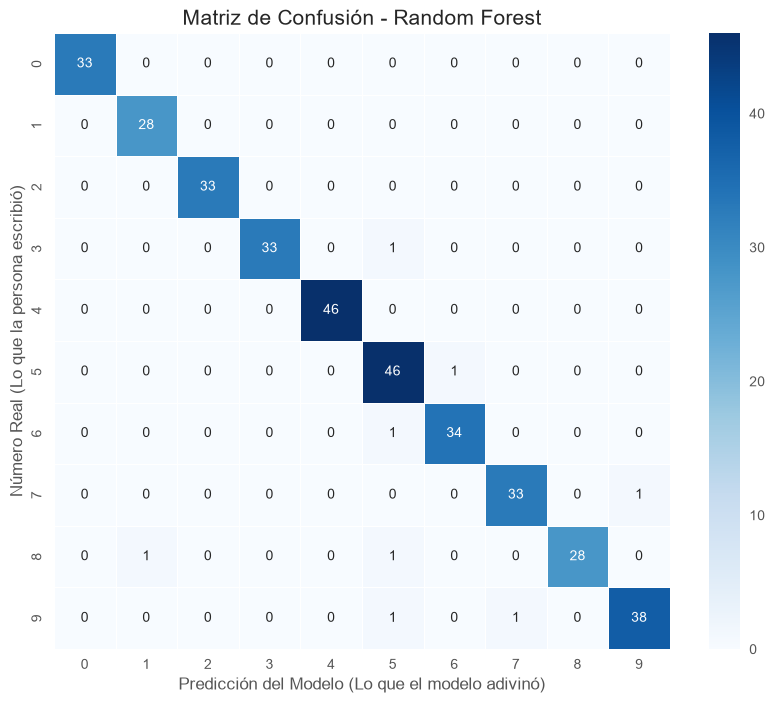

In [47]:
# Calcular la matriz de confusión con los datos reales (y_test) y las predicciones (y_pred)
cm = confusion_matrix(y_test, y_pred)

# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 8))

# Crear el mapa de calor (heatmap)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=range(10), yticklabels=range(10),
    linewidths=.5, square=True
)

# Añadir títulos y etiquetas para que sea fácil de leer
plt.title('Matriz de Confusión - Random Forest', size=15)
plt.ylabel('Número Real (Lo que la persona escribió)', size=12)
plt.xlabel('Predicción del Modelo (Lo que el modelo adivinó)', size=12)

# 5. Mostrar el gráfico
plt.show()

#### Optimizacion de hiperparametros usando busqueda aleatoria

In [49]:
# Clasificador base
rf = RandomForestClassifier(
    min_samples_leaf=1,       # S6973
    max_features="sqrt",      # S6973
    random_state=42
)

# Definicion de la "cuadrícula" (grid) de hiperparámetros a explorar
param_grid = {
    'n_estimators': np.arange(10, 200, 20),       # Cantidad de árboles en el bosque
    'max_depth': [10, 20],          # Profundidad máxima de cada árbol
    'min_samples_split': [2, 5],          # Mínimo de muestras para dividir un nodo
    'min_samples_leaf': [1, 2],           # Mínimo de muestras que debe haber en una "hoja" final
    'criterion': ['gini','entropy']
}

# Configuracion RandomizedSearchCV
grid_search = RandomizedSearchCV(
    estimator=rf,               # El modelo que vamos a usar
    param_distributions=param_grid,      # El diccionario con los parámetros a probar
    cv=5,                       # Validación cruzada de 5 pliegues (divide X_train en 5 partes)
    n_jobs=-1,                  # Usa todos los núcleos de tu procesador para ir más rápido
    scoring='accuracy',          # Métrica a optimizar (exactitud)
    random_state= 42,
    n_iter=15
)

# Iniciar la búsqueda y el entrenamiento
logger.info("Buscando los mejores parámetros... Esto puede tomar unos segundos.")
grid_search.fit(X_train, y_train)

2026-09-16 20:53:51 [INFO] Buscando los mejores parámetros... Esto puede tomar unos segundos.


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy'], 'max_depth': [10, 20], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple 

In [51]:
# Ver los resultados
logger.info("\n¡Búsqueda completada!")
logger.info("Mejores hiperparámetros encontrados: \n%s", grid_search.best_params_)
logger.info("Mejor exactitud durante la validación cruzada: %.2f%%", grid_search.best_score_ * 100)

# Guardar el mejor modelo listo para usarse
best_rf_model = grid_search.best_estimator_

2026-09-16 20:57:48 [INFO] 
¡Búsqueda completada!
2026-09-16 20:57:48 [INFO] Mejores hiperparámetros encontrados: 
{'n_estimators': np.int64(90), 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'criterion': 'entropy'}
2026-09-16 20:57:48 [INFO] Mejor exactitud durante la validación cruzada: 97.29%


In [52]:
# Usar el modelo para predecir las etiquetas de los datos de prueba
y_pred = best_rf_model.predict(X_test)

# Calcular la exactitud (accuracy) general
precision_final = metrics.accuracy_score(y_test, y_pred)
logger.info("Precisión exacta en el conjunto de prueba: %.2f%%", precision_final * 100)

# Generar un reporte detallado para ver cómo le fue con cada número
logger.info("Reporte de Clasificación Detallado:")
report = metrics.classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# redondear y ordenar
df_report = df_report.round(3)
df_report

2026-09-16 20:58:32 [INFO] Precisión exacta en el conjunto de prueba: 97.78%
2026-09-16 20:58:32 [INFO] Reporte de Clasificación Detallado:


,precision,recall,f1-score,support
0,0.970,0.970,0.970,33.000
1,1.000,1.000,1.000,28.000
2,1.000,1.000,1.000,33.000
3,1.000,0.971,0.985,34.000
4,0.979,1.000,0.989,46.000
5,0.939,0.979,0.958,47.000
6,0.971,0.971,0.971,35.000
7,0.971,0.971,0.971,34.000
8,1.000,0.967,0.983,30.000
9,0.974,0.950,0.962,40.000


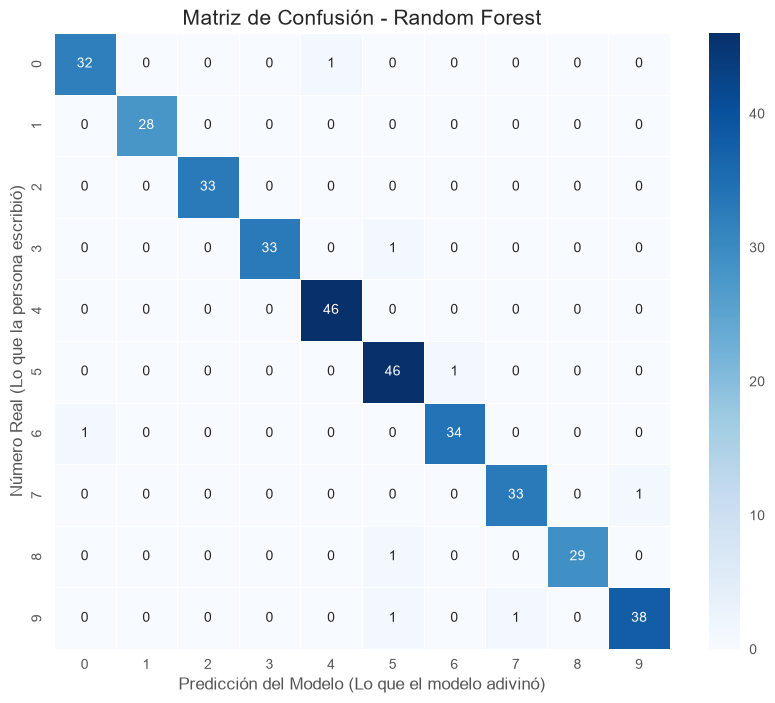

In [53]:
# Calcular la matriz de confusión con los datos reales (y_test) y las predicciones (y_pred)
cm = confusion_matrix(y_test, y_pred)

# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 8))

# Crear el mapa de calor (heatmap)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=range(10), yticklabels=range(10),
    linewidths=.5, square=True
)

# Añadir títulos y etiquetas para que sea fácil de leer
plt.title('Matriz de Confusión - Random Forest', size=15)
plt.ylabel('Número Real (Lo que la persona escribió)', size=12)
plt.xlabel('Predicción del Modelo (Lo que el modelo adivinó)', size=12)

# 5. Mostrar el gráfico
plt.show()

#### Optimizacion de hiperparámetros usando optimización bayesiana

In [55]:
# Clasificador base
rf = RandomForestClassifier(
    min_samples_leaf=1,       # S6973
    max_features="sqrt",      # S6973
    random_state=42
)

# Definicion de la "cuadrícula" (grid) de hiperparámetros a explorar
param_grid = {
    'n_estimators': np.arange(10, 200, 20),       # Cantidad de árboles en el bosque
    'max_depth': [10, 20],          # Profundidad máxima de cada árbol
    'min_samples_split': [2, 5],          # Mínimo de muestras para dividir un nodo
    'min_samples_leaf': [1, 2],           # Mínimo de muestras que debe haber en una "hoja" final
    'criterion': ['gini','entropy']
}

# Configuracion BayesSearchCV
grid_search = BayesSearchCV(
    estimator=rf,               # El modelo que vamos a usar
    search_spaces=param_grid,      # El diccionario con los parámetros a probar
    cv=5,                       # Validación cruzada de 5 pliegues (divide X_train en 5 partes)
    n_jobs=-1,                  # Usa todos los núcleos de tu procesador para ir más rápido
    scoring='accuracy',          # Métrica a optimizar (exactitud)
    random_state= 42,
    n_iter=50
)

# Iniciar la búsqueda y el entrenamiento
logger.info("Buscando los mejores parámetros... Esto puede tomar unos segundos.")
grid_search.fit(X_train, y_train)

D:\Proyectos\optimizacion-ia\.venv\Lib\site-packages\skopt\space\space.py:116: UserWarning: Dimension [10, 20] was inferred to Integer(low=10, high=20, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(10, 20), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
D:\Proyectos\optimizacion-ia\.venv\Lib\site-packages\skopt\space\space.py:116: UserWarning: Dimension [2, 5] was inferred to Integer(low=2, high=5, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(2, 5), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
D:\Proyectos\optimizacion-ia\.venv\Lib\site-packages\skopt\space\space.py:116: UserWarning: Dimension [1, 2] was inferred to Integer(low=1, high=2, prior='uniform', transform='identity'). In upcoming versions of scik

,estimator,RandomForestC...ndom_state=42)
,search_spaces,"{'criterion': ['gini', 'entropy'], 'max_depth': [10, 20], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'accuracy'
,n_jobs,-1
,cv,5
,random_state,42
,optimizer_kwargs,None
,n_iter,50
,fit_params,None
,n_points,1
,iid,'deprecated'


In [56]:
# Ver los resultados
logger.info("\n¡Búsqueda completada!")
logger.info("Mejores hiperparámetros encontrados: \n%s", grid_search.best_params_)
logger.info("Mejor exactitud durante la validación cruzada: %.2f%%", grid_search.best_score_ * 100)

# Guardar el mejor modelo listo para usarse
best_rf_model = grid_search.best_estimator_

2026-09-16 21:08:55 [INFO] 
¡Búsqueda completada!
2026-09-16 21:08:55 [INFO] Mejores hiperparámetros encontrados: 
OrderedDict({'criterion': 'entropy', 'max_depth': 19, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 170})
2026-09-16 21:08:55 [INFO] Mejor exactitud durante la validación cruzada: 97.49%


In [57]:
# Usar el modelo para predecir las etiquetas de los datos de prueba
y_pred = best_rf_model.predict(X_test)

# Calcular la exactitud (accuracy) general
precision_final = metrics.accuracy_score(y_test, y_pred)
logger.info("Precisión exacta en el conjunto de prueba: %.2f%%", precision_final * 100)

# Generar un reporte detallado para ver cómo le fue con cada número
logger.info("Reporte de Clasificación Detallado:")
report = metrics.classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# redondear y ordenar
df_report = df_report.round(3)
df_report

2026-09-16 21:08:55 [INFO] Precisión exacta en el conjunto de prueba: 98.06%
2026-09-16 21:08:55 [INFO] Reporte de Clasificación Detallado:


,precision,recall,f1-score,support
0,1.000,1.000,1.000,33.000
1,1.000,1.000,1.000,28.000
2,1.000,1.000,1.000,33.000
3,1.000,0.971,0.985,34.000
4,1.000,1.000,1.000,46.000
5,0.920,0.979,0.948,47.000
6,0.971,0.971,0.971,35.000
7,0.971,0.971,0.971,34.000
8,1.000,0.967,0.983,30.000
9,0.974,0.950,0.962,40.000


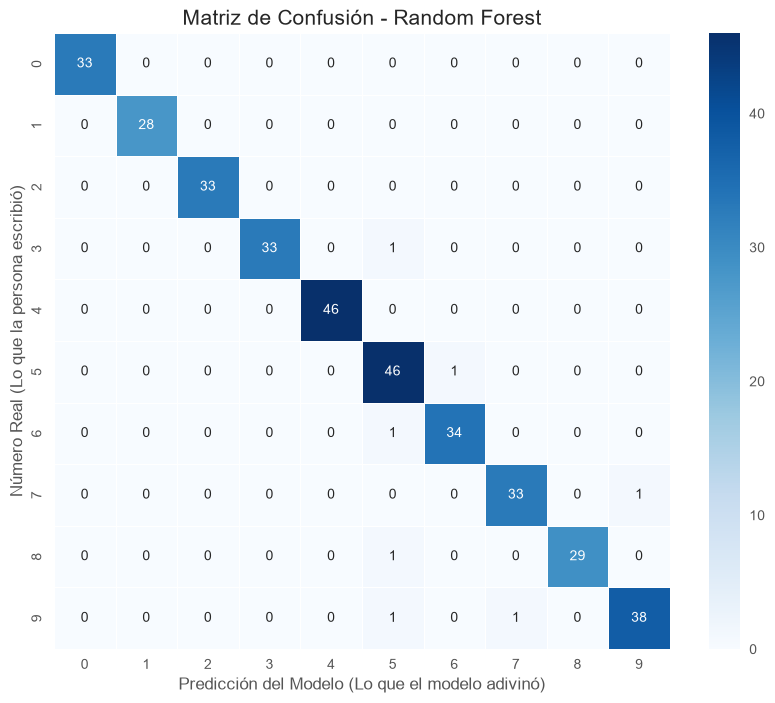

In [58]:
# Calcular la matriz de confusión con los datos reales (y_test) y las predicciones (y_pred)
cm = confusion_matrix(y_test, y_pred)

# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 8))

# Crear el mapa de calor (heatmap)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=range(10), yticklabels=range(10),
    linewidths=.5, square=True
)

# Añadir títulos y etiquetas para que sea fácil de leer
plt.title('Matriz de Confusión - Random Forest', size=15)
plt.ylabel('Número Real (Lo que la persona escribió)', size=12)
plt.xlabel('Predicción del Modelo (Lo que el modelo adivinó)', size=12)

# 5. Mostrar el gráfico
plt.show()

### 2. Regresión

#### Carga de dataset

In [85]:
california = datasets.fetch_california_housing()
"""
MedInc: Ingreso medio en el bloque de viviendas.

HouseAge: Edad media de las casas del bloque.

AveRooms / AveBedrms: Promedio de habitaciones y dormitorios por hogar.

Population: Población del bloque.

AveOccup: Ocupación promedio por hogar.

Latitude / Longitude: Ubicación geográfica del bloque.

MedHouseVal (Target): El valor que queremos predecir (expresado en cientos de miles de dólares, por ejemplo, 4.526 significa $452,600).
"""

logger.debug("contenido de california: \n%s", california.keys())

# Organizando dataframe
df_california = pd.DataFrame(data=california.data, columns=california.feature_names)

# Se agrega la columna correspondiente a la variable objetivo.
df_california['MedHouseVal'] = california.target

estilo_dashboard(df_california.head().T)

2026-09-17 00:10:46 [DEBUG] contenido de california: 
dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


,0,1,2,3,4
MedInc,8.33,8.30,7.26,5.64,3.85
HouseAge,41.00,21.00,52.00,52.00,52.00
AveRooms,6.98,6.24,8.29,5.82,6.28
AveBedrms,1.02,0.97,1.07,1.07,1.08
Population,322.00,2401.00,496.00,558.00,565.00
AveOccup,2.56,2.11,2.80,2.55,2.18
Latitude,37.88,37.86,37.85,37.85,37.85
Longitude,-122.23,-122.22,-122.24,-122.25,-122.25
MedHouseVal,4.53,3.58,3.52,3.41,3.42


##### Análisis Exploratorio de Datos (EDA)

In [62]:
# Correlación directa solo con el Target
correlaciones = df_california.corr()['MedHouseVal'].sort_values(ascending=False)
print("Correlación de cada variable con el precio de la casa:\n")
print(correlaciones)
print("-" * 50)

Correlación de cada variable con el precio de la casa:

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64
--------------------------------------------------


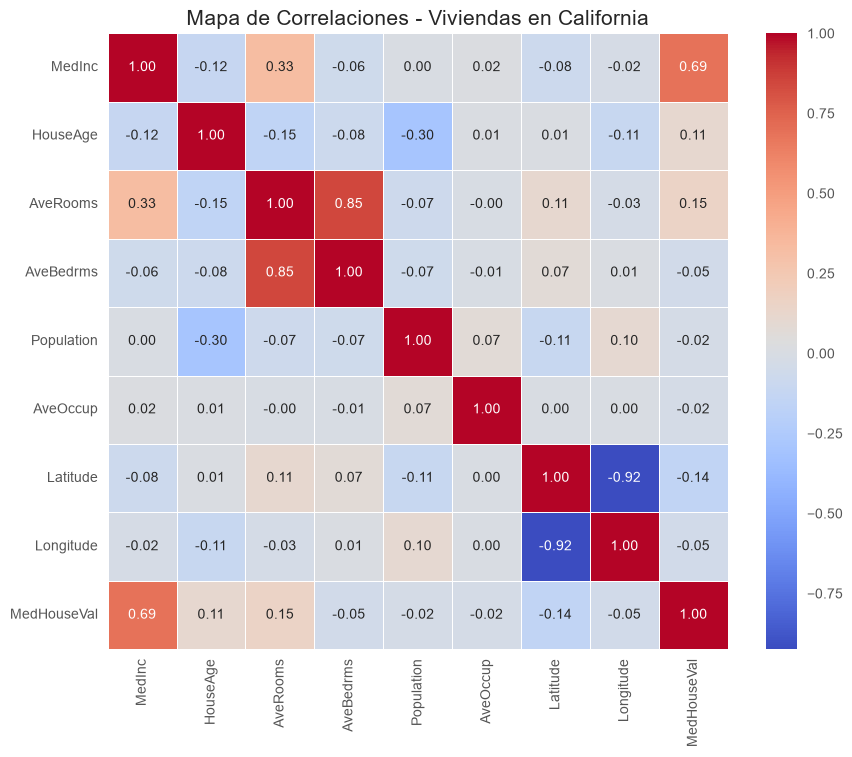

In [63]:
plt.figure(figsize=(10, 8))

# Generamos el mapa de calor usando la matriz de correlación completa (df_california.corr())
sns.heatmap(
    df_california.corr(),
    annot=True,          # Muestra los números dentro de los cuadros
    cmap='coolwarm',     # Colores: rojo para positivo, azul para negativo
    fmt='.2f',           # Muestra solo 2 decimales
    linewidths=0.5
)

plt.title('Mapa de Correlaciones - Viviendas en California', size=15)
plt.show()

La variable con más correlación es: `MedInc`. Esto significa que el ingreso medio dle barrio tiene una correlación positiva muy alta (alrededor de 0.69). Tiene sentido porque en vecindarios donde la gente gana más dinero, las casas son más caras. Relaciones débiles: variables como `Population` o `AveOccup` tienen valores muy cercanos a 0. Esto significa que, por sí solas, no dicen mucho sobre si una casa será barata o cara. Multicolinealidad: el cruce entre `AveRooms` y `AveBedrms`, posee una correlación altísima (cerca de 0.85). Si una casa tiene más cuartos en general, tendrá más dormitorios. Un modelo líneal tendría problemas con esto, en cambio, RF no suele tener problemas con esto.

#### División datos de entrenamiento y prueba

In [64]:
# X contendrá todas las columnas excepto 'MedHouseVal'
X = df_california.drop('MedHouseVal', axis=1)
# y contendrá únicamente el precio de las casas
y = df_california['MedHouseVal']

# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Verificar la cantidad de datos en cada conjunto
print(f"Total de bloques de viviendas originales: {df_california.shape[0]}")
print(f"Bloques para entrenamiento (X_train): {X_train.shape[0]}")
print(f"Bloques para prueba (X_test): {X_test.shape[0]}")

Total de bloques de viviendas originales: 20640
Bloques para entrenamiento (X_train): 14448
Bloques para prueba (X_test): 6192


In [67]:
# modelo base para regresión
rf_regressor = RandomForestRegressor(
    random_state=42
)

# cuadrícula de hiperparámetros
param_grid = {
    'n_estimators': [100, 200],           # Cantidad de árboles
    'max_depth': [None, 15, 25],          # Profundidad máxima (None significa que crecen sin límite)
    'min_samples_split': [2, 5],          # Mínimo de muestras para dividir un nodo
    'criterion': ['squared_error','absolute_error']
}

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_regressor,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring='r2'
)

# Iniciar la búsqueda y el entrenamiento
logger.info("Buscando los mejores parámetros... Esto puede tomar unos segundos.")
grid_search.fit(X_train, y_train)

# Ver los resultados
logger.info("\n¡Búsqueda completada!")
logger.info("Mejores hiperparámetros encontrados: \n%s", grid_search.best_params_)
logger.info("Mejor exactitud durante la validación cruzada: %.2f%%", grid_search.best_score_ * 100)

# Guardar el mejor modelo listo para usarse
best_rf_model = grid_search.best_estimator_

2026-09-16 21:52:17 [INFO] Buscando los mejores parámetros... Esto puede tomar unos segundos.
2026-09-16 21:58:01 [INFO] 
¡Búsqueda completada!
2026-09-16 21:58:01 [INFO] Mejores hiperparámetros encontrados: 
{'criterion': 'absolute_error', 'max_depth': 25, 'min_samples_split': 2, 'n_estimators': 200}
2026-09-16 21:58:01 [INFO] Mejor exactitud durante la validación cruzada: 79.47%


In [69]:
# Usar el mejor modelo para predecir sobre los datos de prueba
y_pred = best_rf_model.predict(X_test)

# Calcular el Error Absoluto Medio (MAE)
mae = metrics.mean_absolute_error(y_test, y_pred)

# Calcular la Raíz del Error Cuadrático Medio (RMSE)
# Primero calculamos el MSE (Error Cuadrático Medio) y le sacamos la raíz cuadrada
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Calcular el R2 en los datos de prueba (para comparar con el de entrenamiento)
r2 = metrics.r2_score(y_test, y_pred)

# Imprimir los resultados con formato
print("=== Resultados en el Conjunto de Prueba ===")
print(f"Puntuación R2: {r2:.4f}")
print(f"Error Absoluto Medio (MAE): {mae:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}")

# Traducción a dólares reales (recordando que el target está en cientos de miles)
print(f"\nEn promedio, el modelo se equivoca por: ${mae * 100000:,.2f} dólares (según MAE).")

=== Resultados en el Conjunto de Prueba ===
Puntuación R2: 0.8062
Error Absoluto Medio (MAE): 0.3325
Raíz del Error Cuadrático Medio (RMSE): 0.5044

En promedio, el modelo se equivoca por: $33,253.86 dólares (según MAE).


In [70]:
historial_metricas = []

historial_metricas.append({
    'Modelo': 'Random Forest (GridSearch)',
    'R2': r2,
    'MAE': mae,
    'RMSE': rmse
})

# Convertir la lista a un DataFrame final para poder comparar
df_comparacion = pd.DataFrame(historial_metricas)

# Mostrar la tabla comparativa ordenada del mejor al peor (basado en R2)
df_comparacion = df_comparacion.sort_values(by='R2', ascending=False).reset_index(drop=True)

print("=== Tabla Comparativa de Modelos ===")
print(df_comparacion)

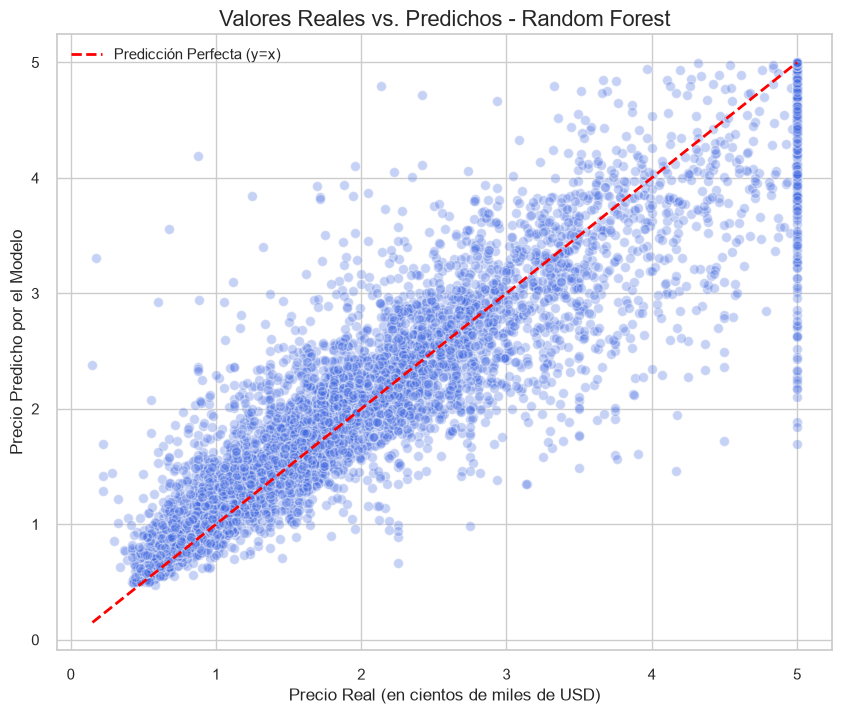

In [71]:
# Configurar el tamaño y estilo del gráfico
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Crear el gráfico de dispersión (scatter plot)
# alpha=0.3 hace que los puntos sean transparentes para ver dónde se agrupan más
plt.scatter(y_test, y_pred, alpha=0.3, color='royalblue', edgecolor='w', s=50)

# Dibujar la línea de "Predicción Perfecta" (y = x)
# Va desde el valor mínimo hasta el valor máximo de los datos reales
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (y=x)')

# Añadir etiquetas y título
plt.title('Valores Reales vs. Predichos - Random Forest', fontsize=16)
plt.xlabel('Precio Real (en cientos de miles de USD)', fontsize=12)
plt.ylabel('Precio Predicho por el Modelo', fontsize=12)
plt.legend()

plt.show()

La forma de nube se puede interpretar como entre más estrecha y pegada a la línea roja esté la nube de puntos azules, mejor es el modelo. Si la nube está muy dispersa el modelo está cometiendo muchos errores. Parece haber un tope de precio en el valor 5.0 ($500,000 USD) esto hará sufrir un poco a los modelos por las características de la casa, demás que hay viviendas más caras, pero limitaron su valor. Valores por encima de la línea roja indica que el modelo sobreestimó el valor (predijo que la casa era más cara de lo que realmente es) y si un punto se encuentra por debajo de la línea, el modelo subestimó el valor (pensó que era más barata)

#### Optimizacion de hiperparametros usando busqueda aleatoria

In [73]:
# modelo base para regresión
rf_regressor = RandomForestRegressor(
    random_state=42
)

# cuadrícula de hiperparámetros
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],           # Cantidad de árboles
    'max_depth': [None, 10, 20, 30, 40, 50],          # Profundidad máxima (None significa que crecen sin límite)
    'min_samples_split': [2, 5, 10],          # Mínimo de muestras para dividir un nodo
    'criterion': ['squared_error','absolute_error'],
    'min_samples_leaf': [1, 2, 4]
}

# Configurar RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_regressor,
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    n_jobs=-1,
    scoring='r2',
    random_state=42
)

# Iniciar la búsqueda y el entrenamiento
logger.info("Buscando los mejores parámetros... Esto puede tomar unos segundos.")
random_search.fit(X_train, y_train)

# Ver los resultados
logger.info("\n¡Búsqueda completada!")
logger.info("Mejores hiperparámetros encontrados: \n%s", random_search.best_params_)
logger.info("Mejor exactitud durante la validación cruzada: %.2f%%", random_search.best_score_ * 100)

# Guardar el mejor modelo listo para usarse
best_rf_random = random_search.best_estimator_

# predicion y metricas
y_pred_random = best_rf_random.predict(X_test)
r2_random = metrics.r2_score(y_test, y_pred_random)
mae_random = metrics.mean_absolute_error(y_test, y_pred_random)
rmse_random = np.sqrt(metrics.mean_squared_error(y_test, y_pred_random))

historial_metricas.append({
    'Modelo': 'Random Forest (RandomizedSearch)',
    'R2': r2_random,
    'MAE': mae_random,
    'RMSE': rmse_random
})

df_comparacion = pd.DataFrame(historial_metricas)
df_comparacion = df_comparacion.sort_values(by='R2', ascending=False).reset_index(drop=True)

print("\n=== Tabla Comparativa de Modelos ===")
print(df_comparacion)

2026-09-16 23:19:00 [INFO] Buscando los mejores parámetros... Esto puede tomar unos segundos.
2026-09-16 23:28:19 [INFO] 
¡Búsqueda completada!
2026-09-16 23:28:19 [INFO] Mejores hiperparámetros encontrados: 
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'criterion': 'absolute_error'}
2026-09-16 23:28:19 [INFO] Mejor exactitud durante la validación cruzada: 79.50%



=== Tabla Comparativa de Modelos ===
                             Modelo        R2       MAE      RMSE
0        Random Forest (GridSearch)  0.806159  0.332539  0.504404
1  Random Forest (RandomizedSearch)  0.806158  0.333269  0.504407


C:\Users\ASUS\AppData\Local\Temp\ipykernel_24308\81253885.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancias, palette='viridis')


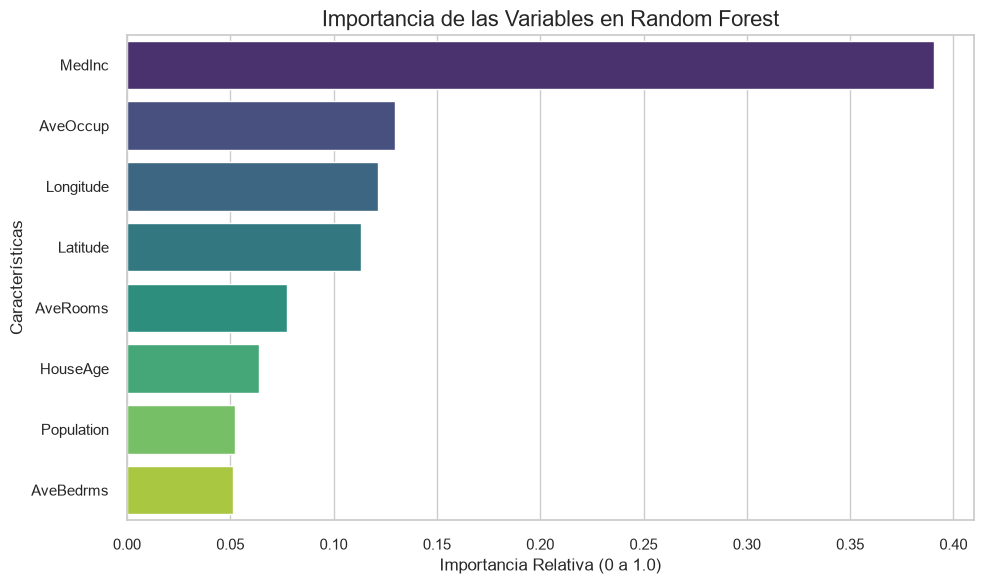


Porcentajes exactos de importancia:
MedInc      : 39.04%
AveOccup    : 12.99%
Longitude   : 12.17%
Latitude    : 11.32%
AveRooms    : 7.72%
HouseAge    : 6.39%
Population  : 5.24%
AveBedrms   : 5.14%


In [74]:
importancias = best_rf_random.feature_importances_

# DataFrame temporal para organizar los datos de mayor a menor
df_importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias
})

# Ordenar los valores para que la variable más importante quede arriba
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)


plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Barplot horizontal (x=Importancia, y=Variable)
sns.barplot(x='Importancia', y='Variable', data=df_importancias, palette='viridis')

plt.title('Importancia de las Variables en Random Forest', fontsize=16)
plt.xlabel('Importancia Relativa (0 a 1.0)', fontsize=12)
plt.ylabel('Características', fontsize=12)

plt.tight_layout()
plt.show()

print("\nPorcentajes exactos de importancia:")
for index, row in df_importancias.iterrows():
    print(f"{row['Variable']:<12}: {row['Importancia']*100:.2f}%")

#### Optimizacion de hiperparámetros usando optimización bayesiana

In [77]:
# modelo base para regresión
rf_regressor = RandomForestRegressor(
    random_state=42
)

# cuadrícula de hiperparámetros
search_space = {
    'n_estimators': Integer(100, 500),         # Cualquier número entero entre 100 y 500
    'max_depth': Integer(10, 50),              # Cualquier número entero entre 10 y 50
    'min_samples_split': Integer(2, 10),       # Cualquier número entero entre 2 y 10
    'min_samples_leaf': Integer(1, 4),          # Cualquier número entero entre 1 y 4
    'criterion': ['squared_error','absolute_error']
}

# Configurar BayesSearchCV
bayes_search = BayesSearchCV(
    estimator=rf_regressor,
    search_spaces=search_space,
    n_iter=15,
    cv=3,
    n_jobs=-1,
    scoring='r2',
    random_state=42,
    verbose=0  # para ver el progreso se pone en 1 o en más
)

# Iniciar la búsqueda y el entrenamiento
logger.info("Buscando los mejores parámetros... Esto puede tomar unos segundos.")
bayes_search.fit(X_train, y_train)

# Ver los resultados
logger.info("\n¡Búsqueda completada!")
logger.info("Mejores hiperparámetros encontrados: \n%s", bayes_search.best_params_)
logger.info("Mejor exactitud durante la validación cruzada: %.2f%%", bayes_search.best_score_ * 100)

# Guardar el mejor modelo listo para usarse
best_rf_bayes = bayes_search.best_estimator_

# predicion y metricas
y_pred_bayes = best_rf_bayes.predict(X_test)
r2_bayes = metrics.r2_score(y_test, y_pred_bayes)
mae_bayes = metrics.mean_absolute_error(y_test, y_pred_bayes)
rmse_bayes = np.sqrt(metrics.mean_squared_error(y_test, y_pred_bayes))

historial_metricas.append({
    'Modelo': 'Random Forest (BayesSearch)',
    'R2': r2_bayes,
    'MAE': mae_bayes,
    'RMSE': rmse_bayes
})

df_comparacion = pd.DataFrame(historial_metricas)
df_comparacion = df_comparacion.sort_values(by='R2', ascending=False).reset_index(drop=True)

print("\n=== Tabla Comparativa de Modelos ===")

2026-09-16 23:38:25 [INFO] Buscando los mejores parámetros... Esto puede tomar unos segundos.
2026-09-16 23:55:34 [INFO] 
¡Búsqueda completada!
2026-09-16 23:55:34 [INFO] Mejores hiperparámetros encontrados: 
OrderedDict({'criterion': 'absolute_error', 'max_depth': 48, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 420})
2026-09-16 23:55:34 [INFO] Mejor exactitud durante la validación cruzada: 79.46%



=== Tabla Comparativa de Modelos ===


In [80]:
estilo_dashboard(df_comparacion)

,Modelo,R2,MAE,RMSE
0,Random Forest (GridSearch),0.81,0.33,0.50
1,Random Forest (RandomizedSearch),0.81,0.33,0.50
2,Random Forest (BayesSearch),0.81,0.33,0.51


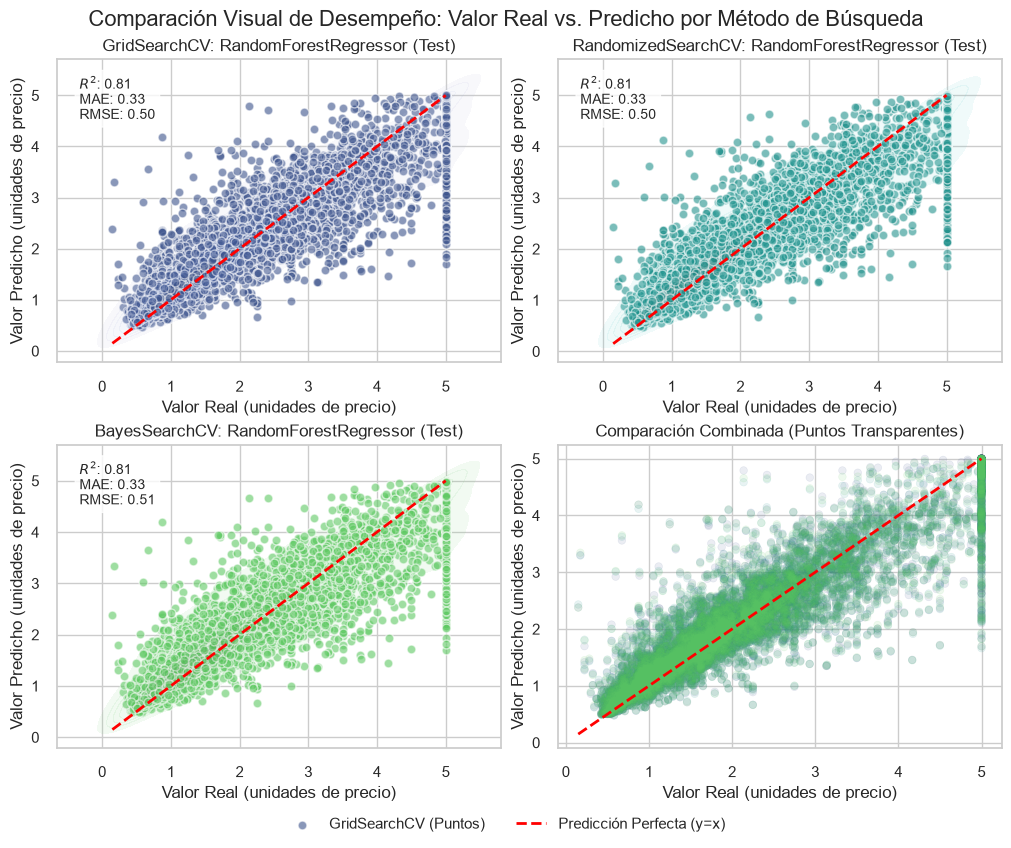

In [81]:
def graficar_comparacion_searchcv(X_test, y_test, searches_dict, combined=True):
    """
    Gráfica la nube de puntos de valores reales vs. predichos para múltiples
    objetos SearchCV en un diseño de cuadrícula o combinado.

    Args:
        X_test: Características del conjunto de prueba.
        y_test: Valores reales del conjunto de prueba.
        searches_dict: Un diccionario donde la clave es el nombre del método
                        (ej: 'GridSearchCV') y el valor es el objeto SearchCV entrenado.
        combined: Si es True, añade un panel final que superpone todos los puntos
                  con alta transparencia para comparación directa.
    """

    sns.set_theme(style="whitegrid")
    num_searches = len(searches_dict)

    # Configurar la cuadrícula de gráficos (máximo 2 columnas)
    cols = 2
    rows = (num_searches + (1 if combined else 0) + 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4), constrained_layout=True)
    fig.suptitle('Comparación Visual de Desempeño: Valor Real vs. Predicho por Método de Búsqueda', fontsize=16)

    # Asegurar que axes sea una lista, incluso si hay un solo gráfico
    axes = np.array(axes).flatten()

    colors = sns.color_palette("viridis", n_colors=num_searches)

    # Línea de predicción perfecta y límites comunes
    min_val = y_test.min()
    max_val = y_test.max()
    perf_line_config = {'color': 'red', 'linestyle': '--', 'linewidth': 2, 'label': 'Predicción Perfecta (y=x)'}

    # DataFrames para la comparación combinada
    combined_dfs = []

    # 1. Graficar cada búsqueda individualmente
    for i, (name, search_obj) in enumerate(searches_dict.items()):
        ax = axes[i]

        # Generar predicciones con el MEJOR estimador encontrado
        best_model = search_obj.best_estimator_
        y_pred = best_model.predict(X_test)

        # Calcular métricas para incluir en el texto
        r2 = metrics.r2_score(y_test, y_pred)
        mae = metrics.mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(np.mean((y_test - y_pred)**2)) # O usar mean_squared_error

        # Guardar para el gráfico combinado
        if combined:
            combined_dfs.append(pd.DataFrame({'Real': y_test, 'Predicho': y_pred, 'Método': name}))

        # Graficar puntos con una nube de densidad suave (alpha bajo)
        ax.scatter(y_test, y_pred, alpha=0.6, color=colors[i], edgecolor='w', s=40, label=f'{name} (Puntos)')

        # Superponer una "nube" más suave para visualizar concentración (similar a la imagen)
        sns.kdeplot(x=y_test, y=y_pred, fill=True, alpha=0.1, color=colors[i], ax=ax)

        # Línea de predicción perfecta
        ax.plot([min_val, max_val], [min_val, max_val], **perf_line_config)

        # Texto con métricas
        textstr = '\n'.join((
            fr'$R^2$: {r2:.2f}',
            fr'MAE: {mae:.2f}',
            fr'RMSE: {rmse:.2f}'
        ))
        props = dict(boxstyle='round', facecolor='white', alpha=0.8)
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=props)

        ax.set_title(f'{name}: {best_model.__class__.__name__} (Test)', fontsize=12)
        ax.set_xlabel('Valor Real (unidades de precio)')
        ax.set_ylabel('Valor Predicho (unidades de precio)')

    # 2. Panel de comparación combinada (puntos muy transparentes)
    if combined:
        ax_combined = axes[num_searches]
        df_all = pd.concat(combined_dfs)

        # Graficar puntos superpuestos con ALTA transparencia
        sns.scatterplot(data=df_all, x='Real', y='Predicho', hue='Método',
                        alpha=0.1, palette=colors, edgecolor=None, s=30, ax=ax_combined)

        ax_combined.plot([min_val, max_val], [min_val, max_val], **perf_line_config)

        ax_combined.set_title('Comparación Combinada (Puntos Transparentes)', fontsize=12)
        ax_combined.set_xlabel('Valor Real (unidades de precio)')
        ax_combined.set_ylabel('Valor Predicho (unidades de precio)')
        ax_combined.get_legend().remove() # Quitar leyenda individual

    # Limpiar ejes extra si hay
    for j in range(num_searches + (1 if combined else 0), len(axes)):
        fig.delaxes(axes[j])

    # Leyenda común
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=num_searches+1, bbox_to_anchor=(0.5, -0.05))

    plt.show()

searches_to_plot = {
    'GridSearchCV': grid_search,
    'RandomizedSearchCV': random_search,
    'BayesSearchCV': bayes_search
}

graficar_comparacion_searchcv(X_test, y_test, searches_to_plot, combined=True)

Los tres métodos de optimización de hiperparámetros (GridSearch, RandomizedSearch y BayesSearch) alcanzaron un rendimiento prácticamente idéntico. La métrica $R^2$ ronda el 0.806 en todos los casos, lo que indica que los modelos explican aproximadamente el 80.6% de la variabilidad de los datos de prueba. Las diferencias en el error (MAE y RMSE) son insignificantes (en el orden de las milésimas).

Eficiencia vs. Precisión: Dado que RandomizedSearch y BayesSearch suelen requerir mucho menos tiempo de cómputo que una búsqueda exhaustiva como GridSearch, y considerando que los resultados son casi iguales, RandomizedSearch surge como la opción más eficiente en este escenario, ofreciendo el mismo nivel de precisión con un menor costo computacional.